# Segmentasi Pelanggan LRFM — Penjualan April-September 2020

Notebook ini dibangun **di atas data bersih** (`bersih/penjualan_bersih.csv`), hasil
`02_pembersihan_dan_anomali.ipynb` — bukan file mentah. Ini bukan pilihan sembarangan:
LRFM menghitung agregat per pelanggan, dan agregat itu rapuh terhadap masalah yang
justru sudah dibereskan di notebook sebelumnya:

- **Duplikat** yang tidak ditandai akan menggelembungkan *Frequency* satu pelanggan.
- **Harga hilang** yang tidak dipulihkan (K03a) akan mengecilkan *Monetary* pelanggan
  yang justru membeli dalam jumlah besar.
- **Identitas pelanggan pecah** (`ADEK FROZEN` vs `C - ADEK FROZEN`) akan membuat satu
  pelanggan terhitung sebagai dua entitas terpisah, masing-masing dengan LRFM yang salah.

**Apa itu LRFM**

Perluasan dari RFM klasik dengan satu dimensi tambahan:

| Huruf | Pertanyaan | Dihitung dari |
|---|---|---|
| **L** — Length | Sudah berapa lama pelanggan ini dikenal? | rentang hari pembelian pertama sampai terakhir |
| **R** — Recency | Berapa lama sejak transaksi terakhirnya? | hari sejak `TGL` terakhir sampai tanggal analisis |
| **F** — Frequency | Seberapa sering dia bertransaksi? | jumlah hari berbeda dia tercatat membeli |
| **M** — Monetary | Berapa besar nilai belanjanya? | total `OMZET` sepanjang periode |

`L` yang membedakan LRFM dari RFM biasa: dua pelanggan bisa punya R, F, M yang mirip,
tapi salah satunya pelanggan lama yang mulai jarang beli, sedangkan satunya pelanggan
baru yang belum sempat menunjukkan pola. Tanpa `L`, keduanya akan disegmentasi sama.

**Alur**

| Bagian | Isi |
|---|---|
| 1 | Muat data bersih & tetapkan cakupan (unit pelanggan mana yang layak dianalisis) |
| 2 | Hitung L, R, F, M mentah per pelanggan |
| 3 | Skoring 1-5 per dimensi (kuantil, bukan ambang tetap) |
| 4 | Peta segmen — aturan eksplisit berbasis skor R x F |
| 5 | Profil & visualisasi tiap segmen |
| 6 | Ekspor


## 1. Muat data bersih & tetapkan cakupan

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FILE_BERSIH = os.path.join('bersih', 'penjualan_bersih.csv')
DIR_KELUARAN = 'bersih'

WARNA_SEGMEN = {
    'Juara': '#2E7D32', 'Pelanggan Setia': '#66BB6A', 'Potensi Setia': '#9CCC65',
    'Pelanggan Baru': '#4C72B0', 'Menjanjikan': '#64B5CD',
    'Butuh Perhatian': '#DD8452', 'Akan Tertidur': '#E8A87C',
    'Berisiko': '#C44E52', 'Jangan Sampai Hilang': '#8C4351', 'Tertidur': '#9AA5B1',
}

# BULAN sengaja TIDAK ikut parse_dates: isinya label bulan ('April 2020'), bukan tanggal.
d = pd.read_csv(FILE_BERSIH, parse_dates=['TGL'])

# Label bulan terbaca sebagai teks biasa, sehingga urutannya akan alfabetis
# (Agustus sebelum April). Urutan kronologis diambil dari TGL, bukan dikarang.
urut_bulan = d.sort_values('TGL')['BULAN'].drop_duplicates().tolist()
d['BULAN'] = pd.Categorical(d['BULAN'], categories=urut_bulan, ordered=True)
print('Dimensi data bersih:', d.shape)
print(f'Periode: {d["TGL"].min():%d %b %Y} s/d {d["TGL"].max():%d %b %Y}')
print(f'Pelanggan unik (mentah): {d["PELANGGAN"].nunique()}')
d.head()

Dimensi data bersih: (6740, 18)
Periode: 01 Apr 2020 s/d 30 Sep 2020
Pelanggan unik (mentah): 181


,BARIS_ASLI,TGL,BULAN,HARI,KODE,NAMA_BARANG,BRAND,QTY,SATUAN,HARGA,HARGA_EFEKTIF,OMZET,RASIO,PELANGGAN,SUMBER_HARGA,TINGKAT_TERTINGGI,SKOR_ANOMALI,FLAG
0,2,2020-04-01,April 2020,Wednesday,JOF-022,JOFRANS NUGGET AYAM REG. 225 GR X 24 PAK,JOFRANS,1.00,DUS,"240,000.00","240,000.00","240,000.00",1.00,TOKO SALMAINI HABABAHAN,asli,bersih,0,NaN
1,3,2020-04-01,April 2020,Wednesday,JOF-002,JOFRANS NUGGET AYAM REG. 500 GR X 12 PAK,JOFRANS,1.00,DUS,"216,000.00","216,000.00","216,000.00",1.00,TOKO SALMAINI HABABAHAN,asli,bersih,0,NaN
2,4,2020-04-01,April 2020,Wednesday,OKEY-003,OKEY STICK 500 GR X 10 PACK,OKEY,1.00,DUS,"190,000.00","190,000.00","190,000.00",1.00,TOKO SALMAINI HABABAHAN,asli,bersih,0,NaN
3,5,2020-04-01,April 2020,Wednesday,OKEY-001,OKEY SOSIS 500 GR X 20 PACK,OKEY,1.00,DUS,"380,000.00","380,000.00","380,000.00",1.00,TOKO SALMAINI HABABAHAN,asli,bersih,0,NaN
4,6,2020-04-01,April 2020,Wednesday,BLF-001,BELFOODS SOSIS AYAM 500 GR X 12 PACK,BELFOODS,1.00,DUS,"204,000.00","204,000.00","204,000.00",1.00,TOKO SALMAINI HABABAHAN,asli,bersih,0,NaN


`CASH` bukan satu pelanggan — ia label transaksi tunai/walk-in yang dipakai untuk
banyak pembeli berbeda yang tidak tercatat identitasnya. Menyertakannya ke LRFM berarti
menjumlahkan riwayat ratusan orang tak terkait jadi satu "pelanggan super", yang akan
selalu muncul sebagai *Juara* semu dan merusak skala kuantil untuk pelanggan lain.
Ia dikeluarkan dari segmentasi, tetapi nilainya tetap dilaporkan terpisah supaya tidak
hilang dari total omzet.

In [2]:
PSEUDO_PELANGGAN = ['CASH']   # bukan identitas pelanggan asli -> dikeluarkan dari LRFM

tunai = d[d['PELANGGAN'].isin(PSEUDO_PELANGGAN)]
valid = d[~d['PELANGGAN'].isin(PSEUDO_PELANGGAN)].copy()

print(f'Baris tunai/walk-in dikeluarkan : {len(tunai):,} '
      f'(Rp {tunai["OMZET"].sum():,.0f}, {tunai["OMZET"].sum() / d["OMZET"].sum() * 100:.1f}% omzet)')
print(f'Baris & pelanggan untuk LRFM    : {len(valid):,} baris, '
      f'{valid["PELANGGAN"].nunique()} pelanggan')

n_sekali = int((valid.groupby('PELANGGAN')['TGL'].nunique() == 1).sum())
print(f'Pelanggan dengan hanya 1 hari transaksi tercatat: {n_sekali} '
      f'— L mereka otomatis 0. Itu bukan kesalahan, hanya belum ada riwayat kedua.')

Baris tunai/walk-in dikeluarkan : 656 (Rp 167,453,770, 3.6% omzet)
Baris & pelanggan untuk LRFM    : 6,084 baris, 180 pelanggan
Pelanggan dengan hanya 1 hari transaksi tercatat: 33 — L mereka otomatis 0. Itu bukan kesalahan, hanya belum ada riwayat kedua.


## 2. Hitung L, R, F, M mentah per pelanggan

Tanggal analisis diambil sehari setelah transaksi terakhir di seluruh dataset
(`2020-09-30 + 1`), bukan tanggal hari ini — supaya Recency mengukur posisi pelanggan
**relatif terhadap akhir periode data**, bukan relatif terhadap kapan notebook ini
kebetulan dijalankan.

`F` dihitung dari **jumlah hari berbeda** pelanggan itu bertransaksi, bukan jumlah baris.
Satu nota dengan 5 SKU sekaligus bukan berarti pelanggan itu "5 kali lebih sering"
belanja — itu tetap satu kunjungan. Menghitung baris akan menghukum pelanggan yang
beli banyak jenis barang sekaligus, padahal itu justru perilaku baik.

In [3]:
TGL_ANALISIS = d['TGL'].max() + pd.Timedelta(days=1)
print(f'Tanggal analisis (H+1 dari transaksi terakhir): {TGL_ANALISIS:%d %b %Y}')

lrfm = valid.groupby('PELANGGAN').agg(
    TANGGAL_PERTAMA=('TGL', 'min'),
    TANGGAL_TERAKHIR=('TGL', 'max'),
    F=('TGL', 'nunique'),
    N_BARIS=('TGL', 'size'),
    M=('OMZET', 'sum'),
    M_RATA_PER_HARI=('OMZET', lambda s: s.sum() / s.index.size),
)
lrfm['L'] = (lrfm['TANGGAL_TERAKHIR'] - lrfm['TANGGAL_PERTAMA']).dt.days
lrfm['R'] = (TGL_ANALISIS - lrfm['TANGGAL_TERAKHIR']).dt.days
lrfm = lrfm.reset_index()

print(f'\n{len(lrfm)} pelanggan diberi nilai LRFM.')
display(lrfm[['L', 'R', 'F', 'M']].describe().round(1))

Tanggal analisis (H+1 dari transaksi terakhir): 01 Oct 2020

180 pelanggan diberi nilai LRFM.


,L,R,F,M
count,180.00,180.00,180.00,180.00
mean,86.00,42.40,7.70,"24,742,208.60"
std,66.40,43.40,10.90,"63,682,600.50"
min,0.00,1.00,1.00,"125,000.00"
25%,20.00,10.00,2.00,"2,446,875.00"
50%,87.50,28.50,4.00,"6,221,700.00"
75%,149.00,63.00,8.00,"18,399,625.00"
max,181.00,178.00,80.00,"547,771,782.00"


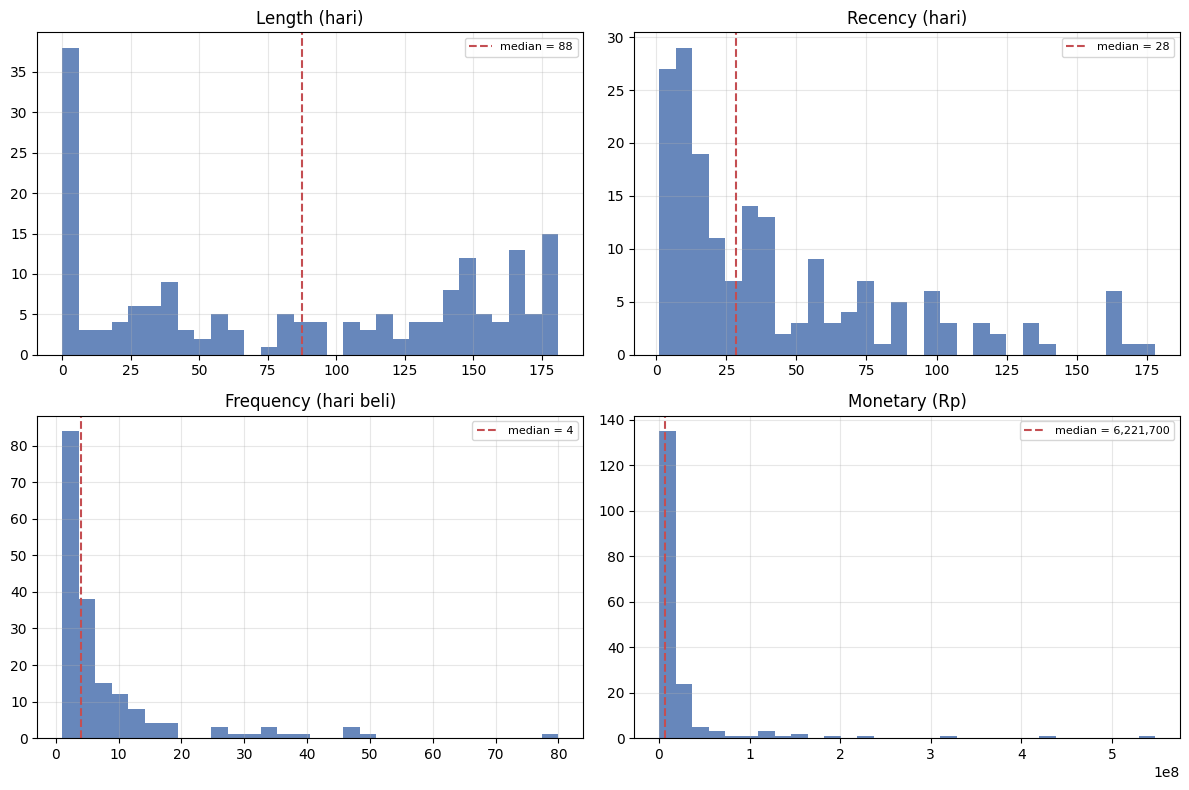

In [4]:
# Sebaran tiap dimensi condong ke kanan (segelintir pelanggan sangat besar), khas
# data transaksi -- alasan yang sama dengan kenapa notebook 02 memakai median+MAD,
# bukan rata-rata, untuk pencilan harga.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, kol, judul in zip(axes.flat, ['L', 'R', 'F', 'M'],
                          ['Length (hari)', 'Recency (hari)', 'Frequency (hari beli)',
                           'Monetary (Rp)']):
    ax.hist(lrfm[kol], bins=30, color='#4C72B0', alpha=0.85)
    ax.axvline(lrfm[kol].median(), color=WARNA_SEGMEN['Berisiko'], ls='--', lw=1.5,
               label=f'median = {lrfm[kol].median():,.0f}')
    ax.set_title(judul)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Skoring 1-5 per dimensi

Skor dibagi lewat **kuantil** (tiap dimensi dipecah jadi 5 kelompok berisi jumlah
pelanggan yang kurang lebih sama), bukan ambang tetap seperti "F >= 10 = sering". Data
6 bulan ini sudah menunjukkan sebaran yang timpang (lihat histogram di atas); ambang
tetap yang masuk akal untuk bulan pertama belum tentu masuk akal begitu periode datanya
berubah. Kuantil menyesuaikan diri terhadap sebaran data itu sendiri.

Arah skor `R` dibalik: Recency yang **kecil** (baru saja beli) mendapat skor **5**,
karena secara bisnis "baru saja aktif" adalah kondisi baik — kebalikan dari L, F, M
yang searah (angka besar = skor besar).

In [5]:
def skor_kuantil(seri, arah_naik=True, k=5):
    '''Bagi seri ke k kelompok berisi jumlah anggota sama lewat kuantil.

    rank(method='first') dipakai sebelum qcut supaya nilai yang sama (mis. banyak
    pelanggan dengan F=1) tetap bisa dipecah ke kelompok berbeda tanpa error
    "duplicate bin edges" -- urutannya tetap stabil karena rank memutus seri
    berdasarkan urutan kemunculan, bukan mengarang nilai.
    '''
    peringkat = seri.rank(method='first')
    label = range(1, k + 1) if arah_naik else range(k, 0, -1)
    return pd.qcut(peringkat, k, labels=list(label)).astype(int)


lrfm['SKOR_L'] = skor_kuantil(lrfm['L'], arah_naik=True)
lrfm['SKOR_R'] = skor_kuantil(lrfm['R'], arah_naik=False)
lrfm['SKOR_F'] = skor_kuantil(lrfm['F'], arah_naik=True)
lrfm['SKOR_M'] = skor_kuantil(lrfm['M'], arah_naik=True)

display(lrfm.groupby('SKOR_R')[['R']].agg(['min', 'max', 'size']))

R          
       min  max size
SKOR_R              
1       72  178   36
2       38   72   36
3       17   38   36
4        7   15   36
5        1    7   36

## 4. Peta segmen

Segmentasi dibuat lewat **satu tabel aturan eksplisit** berbasis kombinasi `SKOR_R` dan
`SKOR_F` — pola yang sama dengan kebijakan pembersihan di notebook 02: keputusan
ditulis di satu tempat, bisa dibaca ulang, dan bisa diubah tanpa menyentuh kode di
sekitarnya. `M` dan `L` sengaja **tidak** ikut menentukan nama segmen; keduanya dipakai
sebagai lensa tambahan saat membaca profil tiap segmen di Bagian 5, supaya segmennya
tetap gampang dijelaskan ("baru & sering beli" vs "baru & sering beli, TAPI nilainya
kecil") tanpa membuat aturannya sendiri jadi rumit.

R dan F dipilih sebagai dasar karena keduanya menjawab pertanyaan paling mendesak untuk
tindakan: *masih aktif?* dan *seberapa lekat kebiasaannya?* — dua hal yang paling cepat
berubah dan paling relevan untuk keputusan retensi.

In [6]:
# Peta standar RF (mis. dari kerangka segmentasi RFM populer), disesuaikan penamaannya.
# Kunci = pola regex atas string "SKOR_R + SKOR_F" (mis. '54' = R skor 5, F skor 4).
PETA_SEGMEN = {
    r'[1-2][1-2]': 'Tertidur',
    r'[1-2][3-4]': 'Berisiko',
    r'[1-2]5':      'Jangan Sampai Hilang',
    r'3[1-2]':      'Akan Tertidur',
    r'33':          'Butuh Perhatian',
    r'[3-4][4-5]':  'Pelanggan Setia',
    r'41':          'Menjanjikan',
    r'51':          'Pelanggan Baru',
    r'[4-5][2-3]':  'Potensi Setia',
    r'5[4-5]':      'Juara',
}

kode_rf = lrfm['SKOR_R'].astype(str) + lrfm['SKOR_F'].astype(str)
lrfm['SEGMEN'] = kode_rf.replace(PETA_SEGMEN, regex=True)

tak_terpetakan = ~lrfm['SEGMEN'].isin(PETA_SEGMEN.values())
assert not tak_terpetakan.any(), f'{tak_terpetakan.sum()} baris tidak kena aturan mana pun.'

urutan_segmen = ['Juara', 'Pelanggan Setia', 'Potensi Setia', 'Pelanggan Baru',
                 'Menjanjikan', 'Butuh Perhatian', 'Akan Tertidur', 'Berisiko',
                 'Jangan Sampai Hilang', 'Tertidur']
lrfm['SEGMEN'] = pd.Categorical(lrfm['SEGMEN'], categories=urutan_segmen, ordered=True)

print('Sebaran pelanggan per segmen:')
display(lrfm['SEGMEN'].value_counts().reindex(urutan_segmen).rename('pelanggan').to_frame())

Sebaran pelanggan per segmen:


,pelanggan
SEGMEN,
Juara,29
Pelanggan Setia,34
Potensi Setia,23
Pelanggan Baru,3
Menjanjikan,2
Butuh Perhatian,5
Akan Tertidur,12
Berisiko,27
Jangan Sampai Hilang,2


## 5. Profil & visualisasi tiap segmen

In [7]:
profil = (lrfm.groupby('SEGMEN', observed=True)
              .agg(pelanggan=('PELANGGAN', 'size'),
                   omzet_total=('M', 'sum'),
                   omzet_rata2=('M', 'mean'),
                   L_median=('L', 'median'),
                   R_median=('R', 'median'),
                   F_median=('F', 'median'),
                   M_median=('M', 'median'),
                   sL=('SKOR_L', 'median'), sR=('SKOR_R', 'median'),
                   sF=('SKOR_F', 'median'), sM=('SKOR_M', 'median'))
              .reindex(urutan_segmen))
profil['pelanggan_%'] = (profil['pelanggan'] / profil['pelanggan'].sum() * 100).round(1)
profil['omzet_%'] = (profil['omzet_total'] / profil['omzet_total'].sum() * 100).round(1)
# Segmen tanpa anggota dibuang supaya semua grafik di bawah aman dipakai ulang
# pada periode data lain, di mana sebuah segmen bisa saja kosong.
profil = profil[profil['pelanggan'].fillna(0) > 0]
tampil = list(profil.index)

display(profil.drop(columns=['sL', 'sR', 'sF', 'sM']))

print(f'\nDicek: {profil["pelanggan_%"].sum():.0f}% pelanggan, '
      f'{profil["omzet_%"].sum():.0f}% omzet -- konsisten dengan seluruh pelanggan valid.')

,pelanggan,omzet_total,omzet_rata2,L_median,R_median,F_median,M_median,pelanggan_%,omzet_%
SEGMEN,,,,,,,,,
Juara,29,"2,180,336,817.00","75,184,028.17",175.00,2.00,17.00,"28,417,000.00",16.10,49.00
Pelanggan Setia,34,"1,417,122,655.00","41,680,078.09",151.00,19.50,8.50,"17,799,250.00",18.90,31.80
Potensi Setia,23,"161,353,900.00","7,015,386.96",35.00,13.00,3.00,"4,618,500.00",12.80,3.60
Pelanggan Baru,3,"4,415,500.00","1,471,833.33",0.00,6.00,1.00,"1,350,000.00",1.70,0.10
Menjanjikan,2,"28,512,410.00","14,256,205.00",0.00,10.50,1.00,"14,256,205.00",1.10,0.60
Butuh Perhatian,5,"27,159,000.00","5,431,800.00",44.00,31.00,4.00,"3,859,500.00",2.80,0.60
Akan Tertidur,12,"119,520,800.00","9,960,066.67",2.00,26.50,1.50,"5,153,150.00",6.70,2.70
Berisiko,27,"217,037,668.00","8,038,432.15",95.00,64.00,4.00,"6,463,578.00",15.00,4.90
Jangan Sampai Hilang,2,"39,210,900.00","19,605,450.00",114.00,63.00,13.50,"19,605,450.00",1.10,0.90



Dicek: 100% pelanggan, 100% omzet -- konsisten dengan seluruh pelanggan valid.


### 5.1 Ukuran segmen: jumlah pelanggan vs kontribusi omzet

Tiga sudut pandang atas fakta yang sama, karena masing-masing menjawab pertanyaan
berbeda: donut menjawab *"berapa porsinya"*, tornado menjawab *"apakah porsi pelanggan
dan porsi omzet sejalan"*, dan marimekko menjawab *"seberapa besar nilai satu pelanggan
di segmen itu"*.


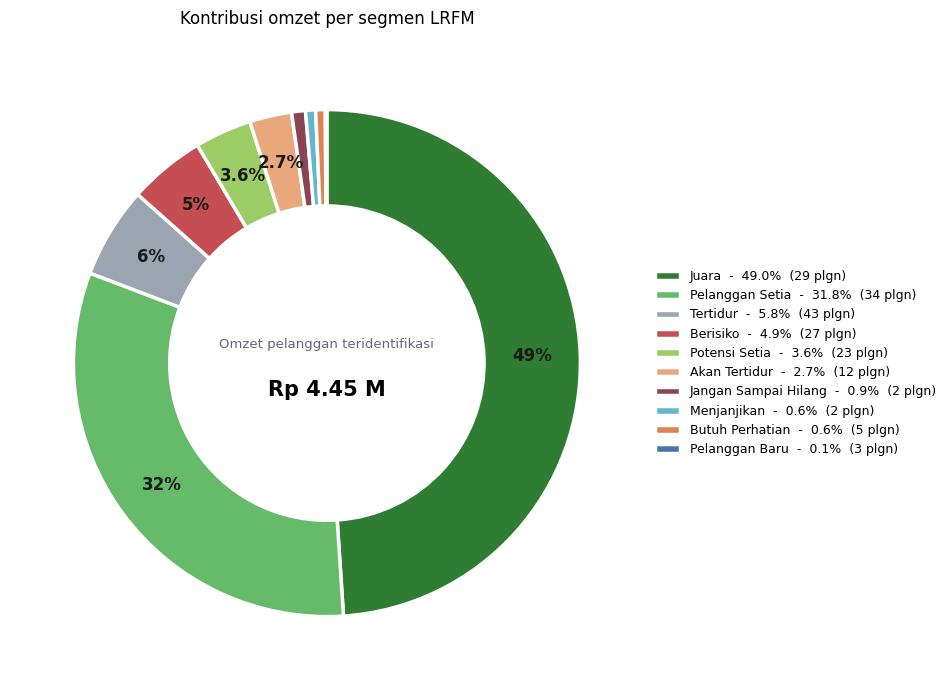

In [8]:
# 5.1a Donut kontribusi omzet per segmen. Irisan di bawah 2,2% tidak diberi label di
# cincin supaya tulisannya tidak saling menimpa -- angkanya tetap ada di legenda.
p = profil.sort_values('omzet_total', ascending=False)
fig, ax = plt.subplots(figsize=(11.5, 7))
w, _, teks = ax.pie(p['omzet_total'], colors=[WARNA_SEGMEN[s] for s in p.index],
                    startangle=90, counterclock=False,
                    wedgeprops=dict(width=0.38, edgecolor='white', lw=2.5),
                    autopct=lambda v: f'{v:.0f}%' if v >= 4 else f'{v:.1f}%',
                    pctdistance=0.81,
                    textprops=dict(fontsize=12, fontweight='bold', color='#1A1A1A'))
for t, wedge in zip(teks, w):
    if (wedge.theta2 - wedge.theta1) / 360 * 100 < 2.2:
        t.set_text('')
ax.text(0, 0.06, 'Omzet pelanggan teridentifikasi', ha='center', fontsize=9.5, color='#667')
ax.text(0, -0.13, f"Rp {p['omzet_total'].sum() / 1e9:.2f} M", ha='center',
        fontsize=15, fontweight='bold')
ax.set_title('Kontribusi omzet per segmen LRFM', fontsize=12, pad=16)
ax.legend(w, [f'{s}  -  {r["omzet_%"]:.1f}%  ({int(r["pelanggan"])} plgn)'
              for s, r in p.iterrows()],
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
plt.tight_layout()
plt.show()


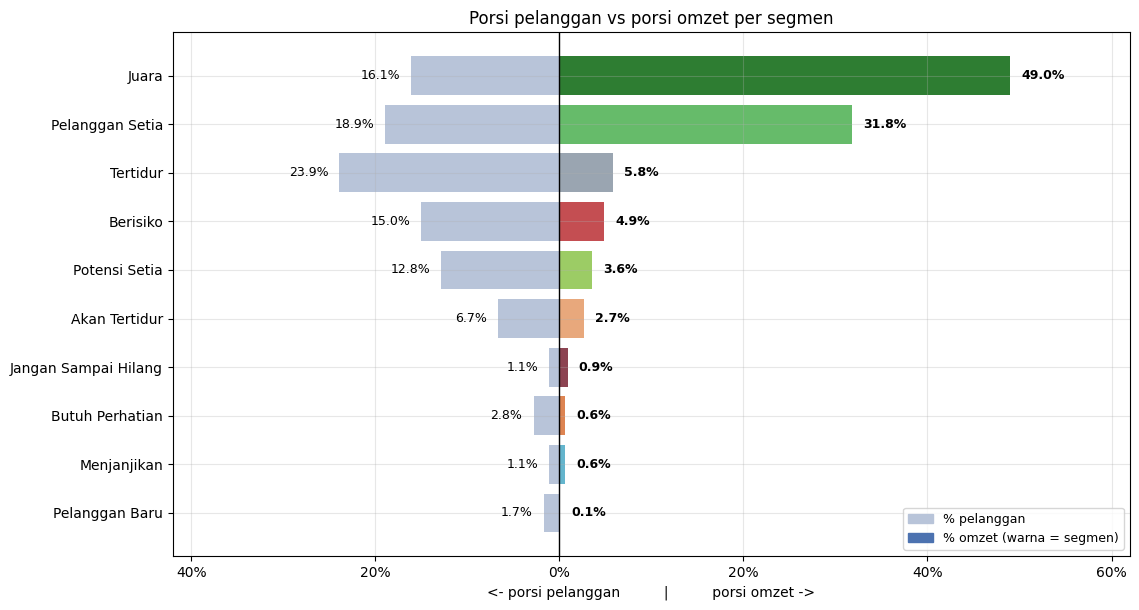

In [9]:
# 5.1b Tornado: porsi pelanggan (kiri) berhadapan dengan porsi omzet (kanan). Segmen
# yang batang kanannya jauh lebih panjang daripada kirinya adalah segmen bernilai tinggi.
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

p2 = profil.sort_values('omzet_%')
fig, ax = plt.subplots(figsize=(11.5, 6.2))
y = np.arange(len(p2))
ax.barh(y, -p2['pelanggan_%'], color='#B8C4D9')
ax.barh(y, p2['omzet_%'], color=[WARNA_SEGMEN[s] for s in p2.index])
for i, (s, r) in enumerate(p2.iterrows()):
    ax.text(-r['pelanggan_%'] - 1.2, i, f'{r["pelanggan_%"]:.1f}%',
            ha='right', va='center', fontsize=9)
    ax.text(r['omzet_%'] + 1.2, i, f'{r["omzet_%"]:.1f}%',
            ha='left', va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y, p2.index)
ax.axvline(0, color='black', lw=1)
ax.set_xlim(-42, 62)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{abs(v):.0f}%'))
ax.set_xlabel('<- porsi pelanggan          |          porsi omzet ->')
ax.set_title('Porsi pelanggan vs porsi omzet per segmen')
ax.legend(handles=[Patch(color='#B8C4D9', label='% pelanggan'),
                   Patch(color='#4C72B0', label='% omzet (warna = segmen)')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


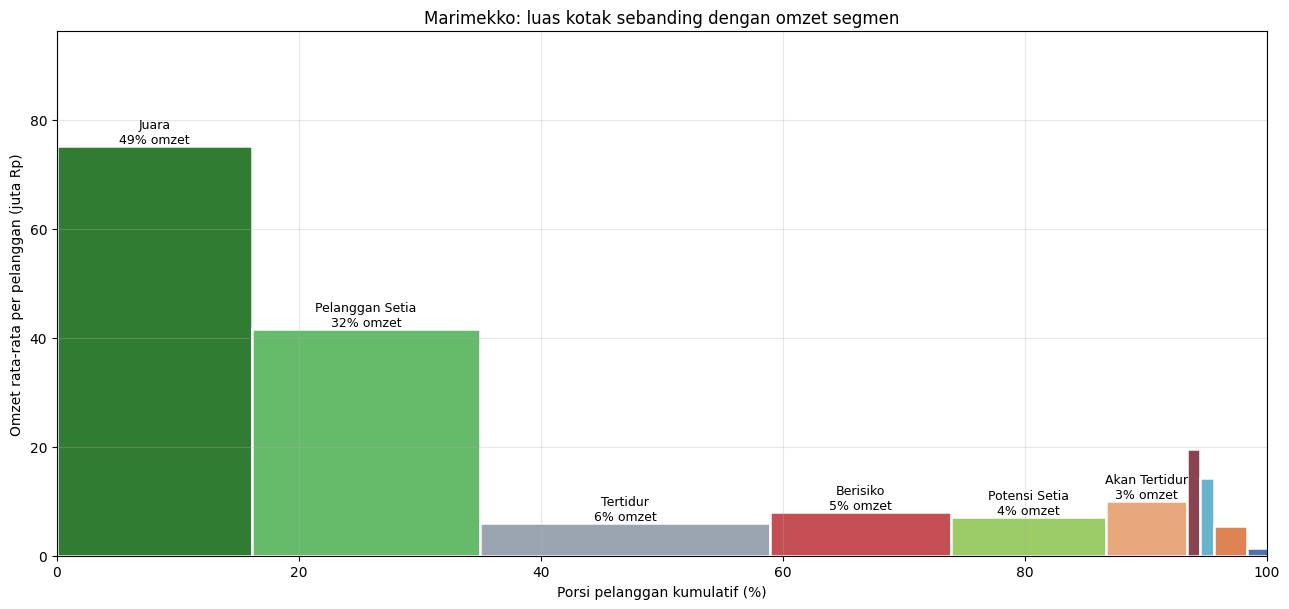

In [10]:
# 5.1c Marimekko: lebar kotak = porsi pelanggan, tinggi = omzet rata-rata per
# pelanggan. Luas kotak jadi sebanding dengan omzet segmen -- satu gambar yang langsung
# menunjukkan "pelanggannya sedikit, tetapi nilai per kepalanya besar".
from matplotlib.patches import Rectangle

p3 = profil.sort_values('omzet_total', ascending=False)
fig, ax = plt.subplots(figsize=(13, 6.2))
x = 0.0
for s, r in p3.iterrows():
    lebar = r['pelanggan_%']
    tinggi = r['omzet_total'] / r['pelanggan'] / 1e6
    ax.add_patch(Rectangle((x, 0), lebar, tinggi, color=WARNA_SEGMEN[s], ec='white', lw=1.8))
    if r['omzet_%'] >= 2:
        ax.text(x + lebar / 2, tinggi, f'{s}\n{r["omzet_%"]:.0f}% omzet',
                ha='center', va='bottom', fontsize=9)
    x += lebar
ax.set_xlim(0, 100)
ax.set_ylim(0, (p3['omzet_total'] / p3['pelanggan']).max() / 1e6 * 1.28)
ax.set_xlabel('Porsi pelanggan kumulatif (%)')
ax.set_ylabel('Omzet rata-rata per pelanggan (juta Rp)')
ax.set_title('Marimekko: luas kotak sebanding dengan omzet segmen')
plt.tight_layout()
plt.show()


### 5.2 Detail profil tiap segmen

Bagian 5.1 hanya menunjukkan *besar* segmen. Di sini isinya: seperti apa nilai L, R, F,
dan M khas anggota tiap segmen. Tiga bentuk yang saling melengkapi -- heatmap untuk
membaca angka persisnya, radar untuk mengenali *bentuk* segmen dalam sekali lihat, dan
boxplot untuk melihat seberapa seragam anggota di dalamnya.


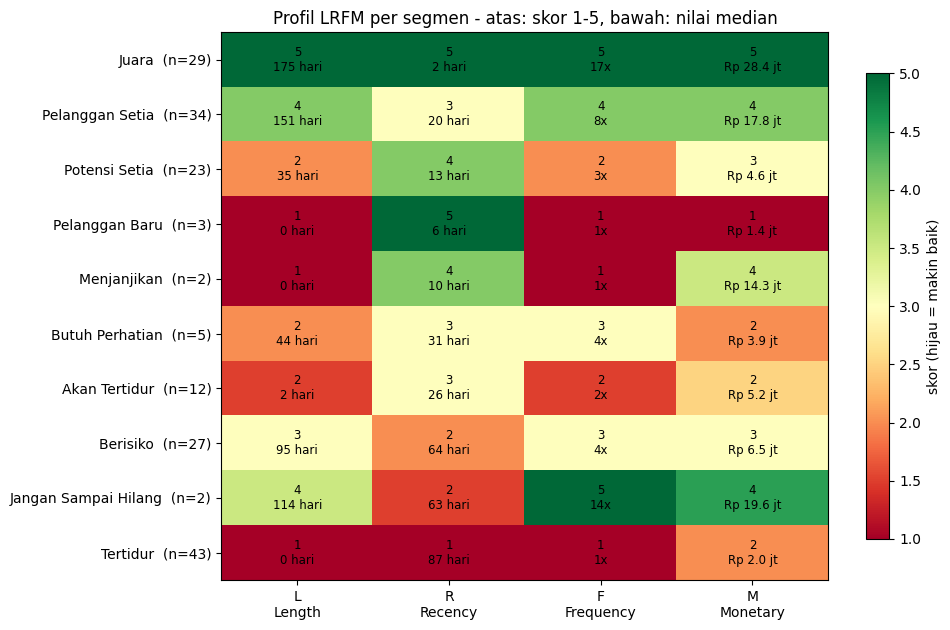

In [11]:
# 5.2a Heatmap profil: warna mengikuti skor kuantil 1-5 sehingga hijau selalu berarti
# "baik" di keempat kolom (arah R sudah dibalik saat skoring), sementara angka median
# aslinya tetap tercetak supaya besarannya tidak hilang di balik warna.
skor = profil[['sL', 'sR', 'sF', 'sM']].astype(float)
asli = profil[['L_median', 'R_median', 'F_median', 'M_median']]
format_nilai = [lambda v: f'{v:.0f} hari', lambda v: f'{v:.0f} hari',
                lambda v: f'{v:.0f}x', lambda v: f'Rp {v / 1e6:.1f} jt']

fig, ax = plt.subplots(figsize=(10, 6.4))
im = ax.imshow(skor.values, cmap='RdYlGn', vmin=1, vmax=5, aspect='auto')
ax.set_xticks(range(4), ['L\nLength', 'R\nRecency', 'F\nFrequency', 'M\nMonetary'])
ax.set_yticks(range(len(profil)),
              [f'{s}  (n={int(profil.loc[s, "pelanggan"])})' for s in profil.index])
for i in range(len(profil)):
    for j in range(4):
        ax.text(j, i, f'{skor.values[i, j]:.0f}\n{format_nilai[j](asli.values[i, j])}',
                ha='center', va='center', fontsize=8.5)
ax.set_title('Profil LRFM per segmen - atas: skor 1-5, bawah: nilai median')
ax.grid(False)
fig.colorbar(im, ax=ax, label='skor (hijau = makin baik)', shrink=0.85)
plt.tight_layout()
plt.show()


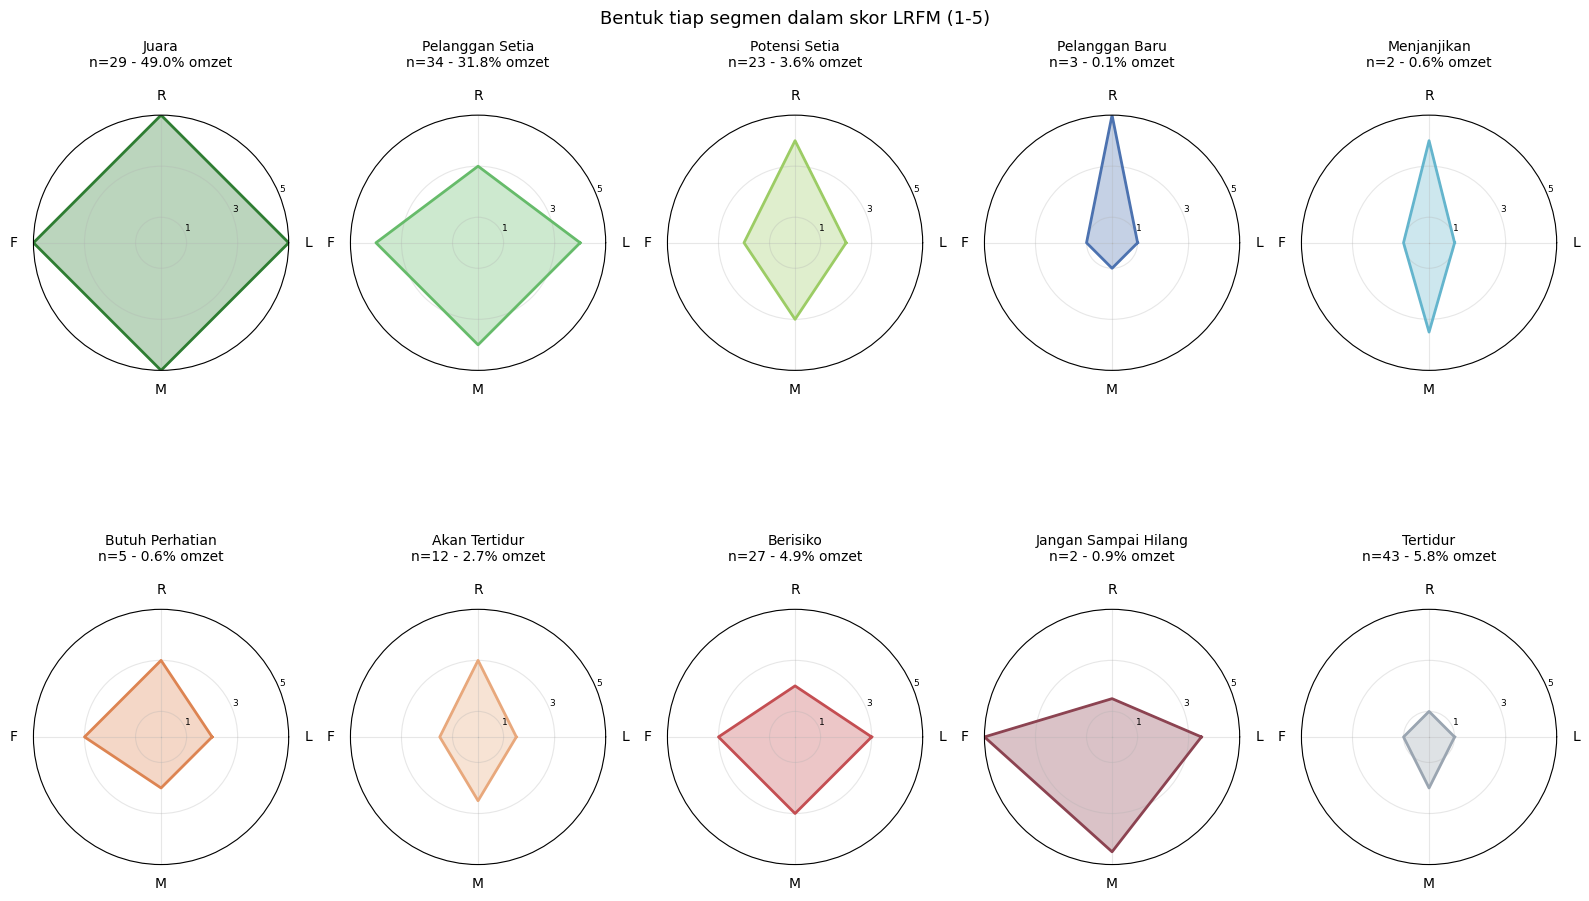

In [12]:
# 5.2b Radar per segmen. Yang dibaca adalah bentuknya: belah ketupat penuh = kuat di
# semua dimensi; bentuk runcing ke satu arah = segmen yang hanya unggul di satu hal
# (mis. "Pelanggan Baru" runcing di R saja -- baru beli, tetapi belum punya riwayat).
sudut = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
sudut += sudut[:1]

n_kol = 5
n_bar = int(np.ceil(len(profil) / n_kol))
fig, axes = plt.subplots(n_bar, n_kol, figsize=(16, 4.6 * n_bar), subplot_kw=dict(polar=True))
for ax, s in zip(np.ravel(axes), profil.index):
    nilai = profil.loc[s, ['sL', 'sR', 'sF', 'sM']].astype(float).tolist()
    nilai += nilai[:1]
    ax.plot(sudut, nilai, color=WARNA_SEGMEN[s], lw=2)
    ax.fill(sudut, nilai, color=WARNA_SEGMEN[s], alpha=0.32)
    ax.set_xticks(sudut[:-1], ['L', 'R', 'F', 'M'], fontsize=10)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 3, 5])
    ax.set_yticklabels(['1', '3', '5'], fontsize=6.5)
    ax.set_title(f'{s}\nn={int(profil.loc[s, "pelanggan"])} - '
                 f'{profil.loc[s, "omzet_%"]:.1f}% omzet', fontsize=10, pad=16)
for ax in np.ravel(axes)[len(profil):]:
    ax.set_visible(False)
fig.suptitle('Bentuk tiap segmen dalam skor LRFM (1-5)', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(hspace=0.55, top=0.90)
plt.show()


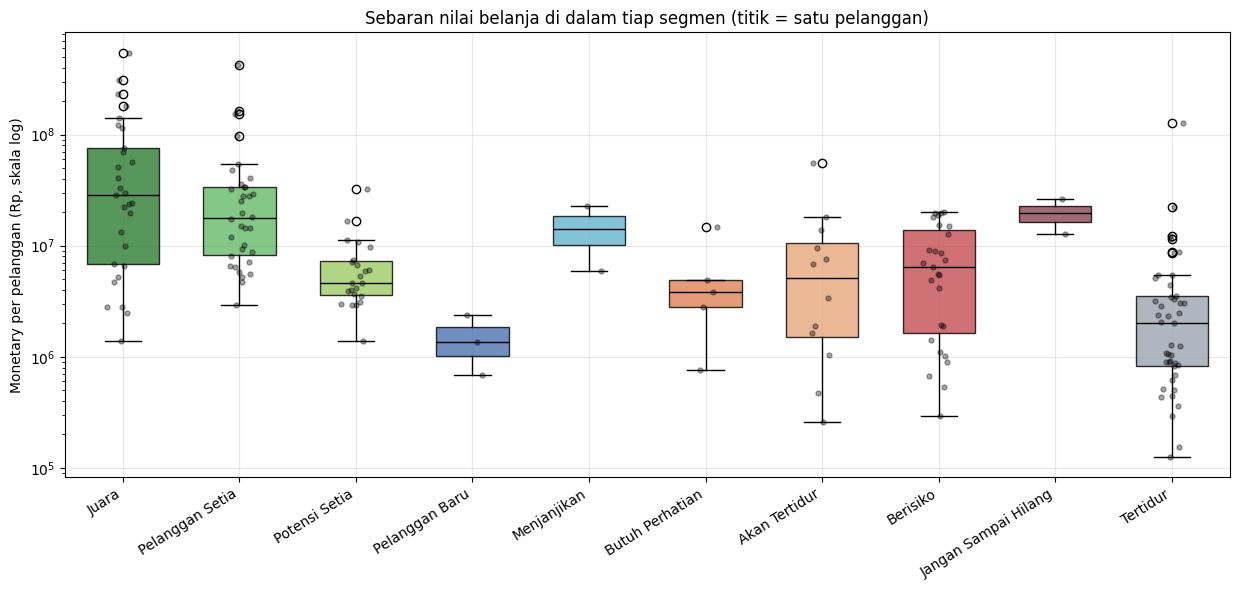

In [13]:
# 5.2c Sebaran nilai belanja DI DALAM tiap segmen. Median saja menyembunyikan
# keragaman: satu segmen bisa memuat pelanggan Rp 1 juta sampai Rp 500 juta sekaligus,
# dan itu berarti perlakuan seragam untuk seluruh segmen belum tentu tepat.
fig, ax = plt.subplots(figsize=(12.5, 6))
data = [lrfm.loc[lrfm['SEGMEN'] == s, 'M'].values for s in profil.index]
bp = ax.boxplot(data, patch_artist=True, widths=0.62, tick_labels=list(profil.index))
for kotak, s in zip(bp['boxes'], profil.index):
    kotak.set_facecolor(WARNA_SEGMEN[s])
    kotak.set_alpha(0.8)
for garis in bp['medians']:
    garis.set_color('black')
acak = np.random.default_rng(0)
for i, s in enumerate(profil.index):
    v = lrfm.loc[lrfm['SEGMEN'] == s, 'M']
    ax.scatter(acak.normal(i + 1, 0.06, len(v)), v, s=13, color='black', alpha=0.35, zorder=3)
ax.set_yscale('log')
ax.set_ylabel('Monetary per pelanggan (Rp, skala log)')
ax.set_title('Sebaran nilai belanja di dalam tiap segmen (titik = satu pelanggan)')
plt.xticks(rotation=32, ha='right')
plt.tight_layout()
plt.show()


### 5.3 Peta posisi pelanggan

Dua peta yang saling melengkapi: grid 5x5 menunjukkan *aturan* segmentasinya (versi
visual dari `PETA_SEGMEN`), sedangkan sebar-titik menunjukkan pelanggan sungguhan di
atas sumbu aslinya -- termasuk yang duduk tepat di perbatasan antar segmen.


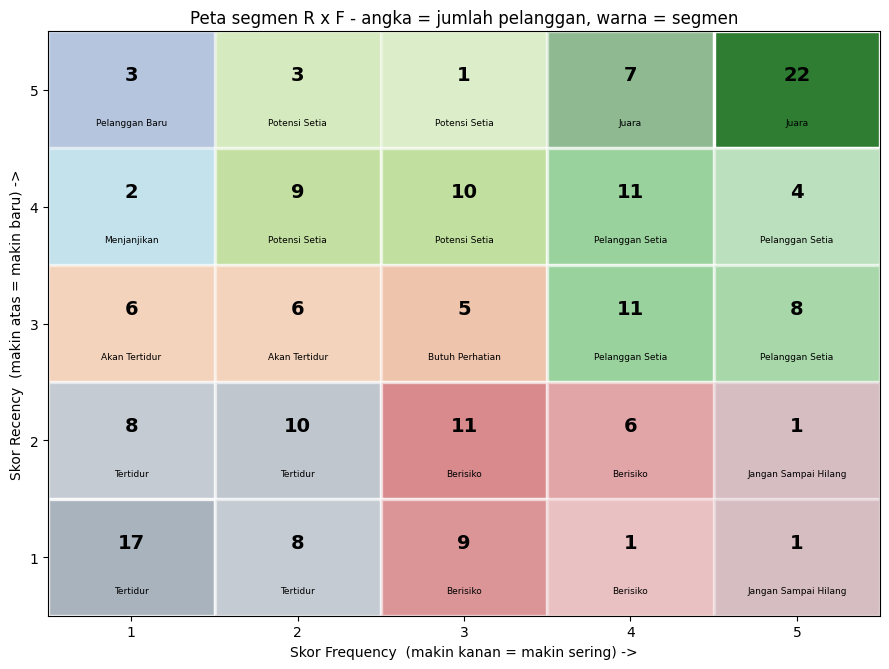

In [14]:
# 5.3a Grid R x F diwarnai menurut segmen yang menempel pada tiap sel, bukan skala
# warna netral: ini membuat tabel aturan PETA_SEGMEN bisa dibaca sebagai gambar.
grid = lrfm.groupby(['SKOR_R', 'SKOR_F'], observed=True).size().unstack(fill_value=0)
grid = grid.reindex(index=range(5, 0, -1), columns=range(1, 6), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6.8))
for i, r in enumerate(range(5, 0, -1)):
    for j, f in enumerate(range(1, 6)):
        nama = pd.Series([f'{r}{f}']).replace(PETA_SEGMEN, regex=True).iloc[0]
        n = grid.loc[r, f]
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color=WARNA_SEGMEN[nama],
                                   alpha=0.32 + 0.68 * (n / max(grid.values.max(), 1)),
                                   ec='white', lw=2.4))
        ax.text(j, i - 0.13, str(n), ha='center', va='center', fontsize=14, fontweight='bold')
        ax.text(j, i + 0.28, nama, ha='center', va='center', fontsize=6.5)
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(4.5, -0.5)
ax.set_xticks(range(5), range(1, 6))
ax.set_yticks(range(5), range(5, 0, -1))
ax.set_xlabel('Skor Frequency  (makin kanan = makin sering) ->')
ax.set_ylabel('Skor Recency  (makin atas = makin baru) ->')
ax.set_title('Peta segmen R x F - angka = jumlah pelanggan, warna = segmen')
ax.grid(False)
plt.tight_layout()
plt.show()


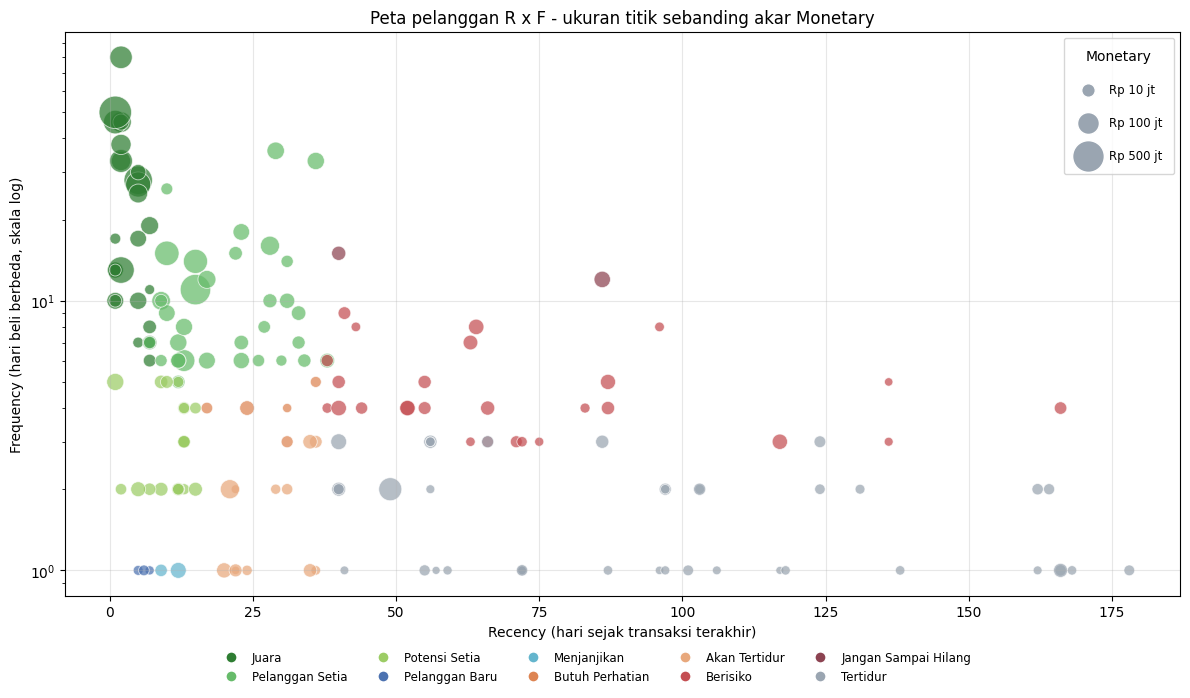

In [15]:
# 5.3b Sebar-titik R x F pada satuan aslinya (hari), ukuran titik mengikuti akar
# Monetary supaya pelanggan raksasa tidak menelan seluruh gambar. Sumbu F memakai skala
# log karena sebarannya sangat condong: mayoritas 1-5 kali, segelintir sampai 80 kali.
fig, ax = plt.subplots(figsize=(12, 6.6))
for s in profil.index:
    sub = lrfm[lrfm['SEGMEN'] == s]
    ax.scatter(sub['R'], sub['F'], s=25 + np.sqrt(sub['M'] / lrfm['M'].max()) * 520,
               color=WARNA_SEGMEN[s], alpha=0.72, edgecolor='white', lw=0.6, label=s)
ax.set_yscale('log')
ax.set_xlabel('Recency (hari sejak transaksi terakhir)')
ax.set_ylabel('Frequency (hari beli berbeda, skala log)')
ax.set_title('Peta pelanggan R x F - ukuran titik sebanding akar Monetary')

# Dua legenda dengan peran berbeda: ukuran titik di dalam sumbu (karena ia menjelaskan
# skala gambar), warna segmen di bawah gambar lewat fig.legend supaya tidak terpotong.
from matplotlib.lines import Line2D

pegangan_segmen = [Line2D([], [], marker='o', ls='', markersize=8, markeredgecolor='white',
                          color=WARNA_SEGMEN[s], label=s) for s in profil.index]
pegangan_ukuran = [ax.scatter([], [], s=25 + np.sqrt(v / lrfm['M'].max()) * 520,
                              color='#9AA5B1', edgecolor='white', label=f'Rp {v / 1e6:.0f} jt')
                   for v in (10e6, 100e6, 500e6)]
ax.legend(handles=pegangan_ukuran, loc='upper right', fontsize=8.5, title='Monetary',
          labelspacing=1.7, borderpad=1.0)
fig.legend(handles=pegangan_segmen, loc='lower center', ncol=5, fontsize=8.5,
           frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()


### 5.4 Pergerakan segmen sepanjang waktu

Segmen dihitung dari seluruh periode sekaligus, jadi label segmen bersifat tetap per
pelanggan. Yang berubah tiap bulan adalah *kontribusi omzetnya* -- berguna untuk
melihat apakah ketergantungan pada segmen tertentu menguat atau melemah.


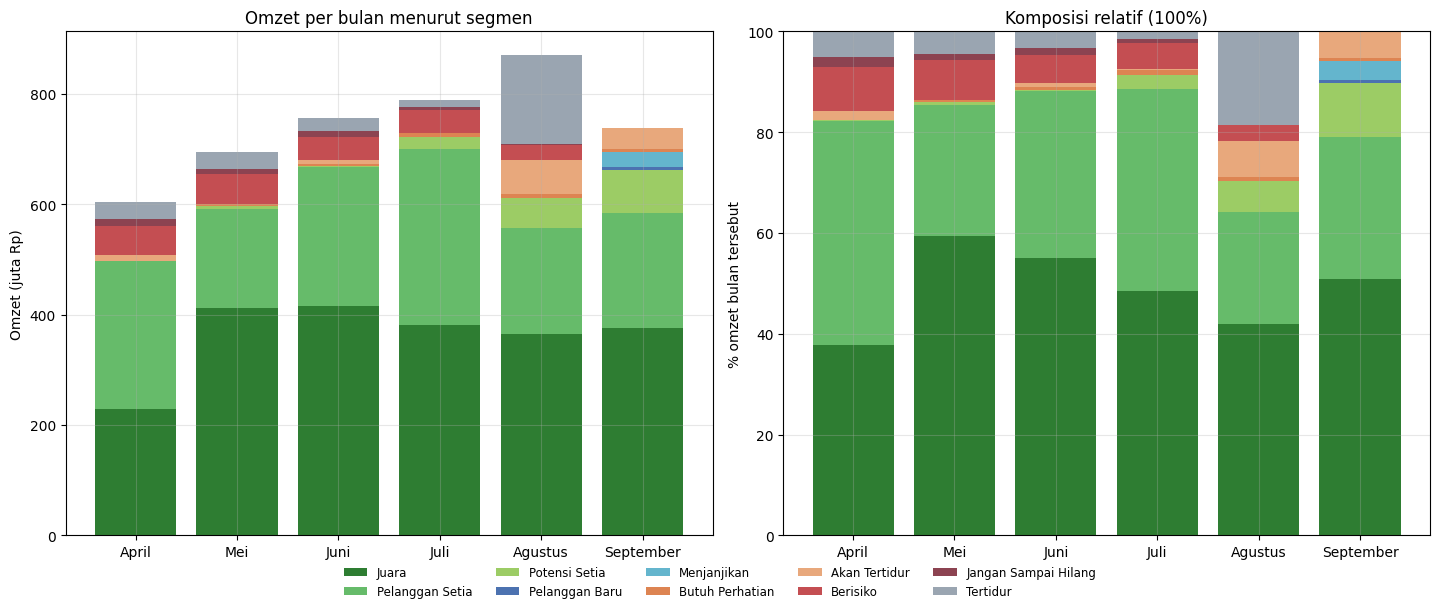

In [16]:
# 5.4 Omzet bulanan per segmen: nominal (kiri) dan komposisi 100% (kanan). Keduanya
# perlu, karena bulan dengan omzet total tinggi bisa saja komposisinya justru memburuk.
transaksi = valid.merge(lrfm[['PELANGGAN', 'SEGMEN']], on='PELANGGAN')
piv = (transaksi.pivot_table(index='BULAN', columns='SEGMEN', values='OMZET',
                             aggfunc='sum', fill_value=0, observed=True)
       .reindex(columns=list(profil.index), fill_value=0))
label_bulan = [str(b).split()[0] for b in piv.index]

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))
dasar = np.zeros(len(piv))
for s in profil.index:
    axes[0].bar(label_bulan, piv[s] / 1e6, bottom=dasar, color=WARNA_SEGMEN[s], label=s)
    dasar += piv[s].values / 1e6
axes[0].set_ylabel('Omzet (juta Rp)')
axes[0].set_title('Omzet per bulan menurut segmen')

persen = piv.div(piv.sum(axis=1), axis=0) * 100
dasar = np.zeros(len(piv))
for s in profil.index:
    axes[1].bar(label_bulan, persen[s], bottom=dasar, color=WARNA_SEGMEN[s])
    dasar += persen[s].values
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('% omzet bulan tersebut')
axes[1].set_title('Komposisi relatif (100%)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8.5, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()


### 5.5 Korelasi antar dimensi LRFM dan terhadap omzet

Pertanyaannya: dimensi mana yang paling menentukan besarnya belanja pelanggan, dan
apakah ada dua dimensi yang sebenarnya mengukur hal yang sama?

Korelasi dihitung dengan **Spearman** (korelasi peringkat), bukan Pearson. Alasannya
sama dengan alasan notebook 02 memakai median dan MAD: keempat dimensi ini condong
berat: satu pelanggan Rp 548 juta di tengah median Rp 6,2 juta. Pearson mengukur
kelurusan hubungan dan akan didominasi segelintir raksasa itu; Spearman hanya
memedulikan urutan, sehingga menjawab pertanyaan yang sebenarnya kita ajukan --
*"pelanggan yang lebih sering beli, apakah cenderung berbelanja lebih besar?"*
Keduanya tetap ditampilkan berdampingan supaya selisihnya terlihat, karena selisih itu
sendiri adalah bukti kecondongan datanya.


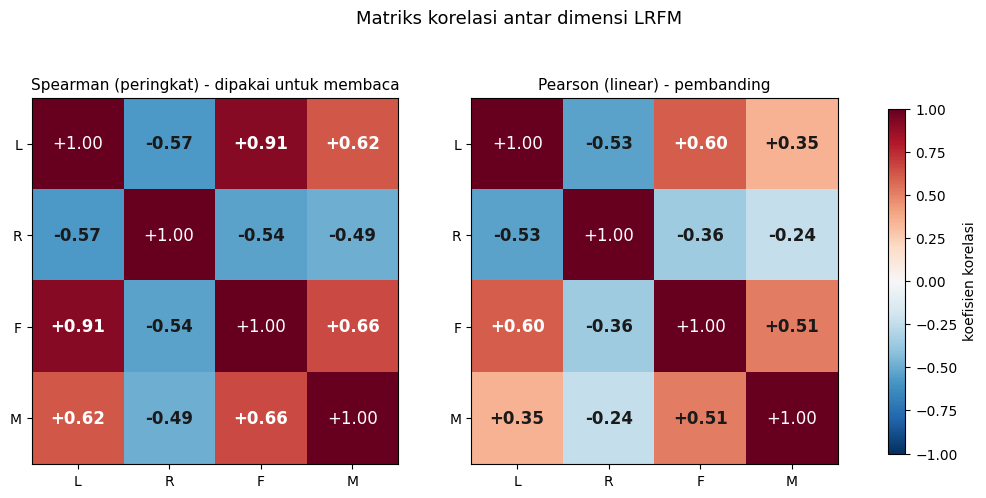

Korelasi terhadap Monetary (Spearman):
  F vs M : +0.66
  L vs M : +0.62
  R vs M : -0.49


In [17]:
# 5.5a Dua matriks korelasi berdampingan: Spearman (peringkat) dan Pearson (linear).
DIMENSI = ['L', 'R', 'F', 'M']
spearman = lrfm[DIMENSI].corr('spearman')
pearson = lrfm[DIMENSI].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
for ax, mat, judul in zip(axes, [spearman, pearson],
                          ['Spearman (peringkat) - dipakai untuk membaca',
                           'Pearson (linear) - pembanding']):
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(4), DIMENSI)
    ax.set_yticks(range(4), DIMENSI)
    for i in range(4):
        for j in range(4):
            v = mat.values[i, j]
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=12,
                    fontweight='bold' if i != j else 'normal',
                    color='white' if abs(v) > 0.6 else '#1A1A1A')
    ax.set_title(judul, fontsize=11)
    ax.grid(False)
fig.colorbar(im, ax=axes, label='koefisien korelasi', shrink=0.8)
fig.suptitle('Matriks korelasi antar dimensi LRFM', fontsize=13)
plt.show()

print('Korelasi terhadap Monetary (Spearman):')
for k, v in spearman['M'].drop('M').sort_values(key=abs, ascending=False).items():
    print(f'  {k} vs M : {v:+.2f}')


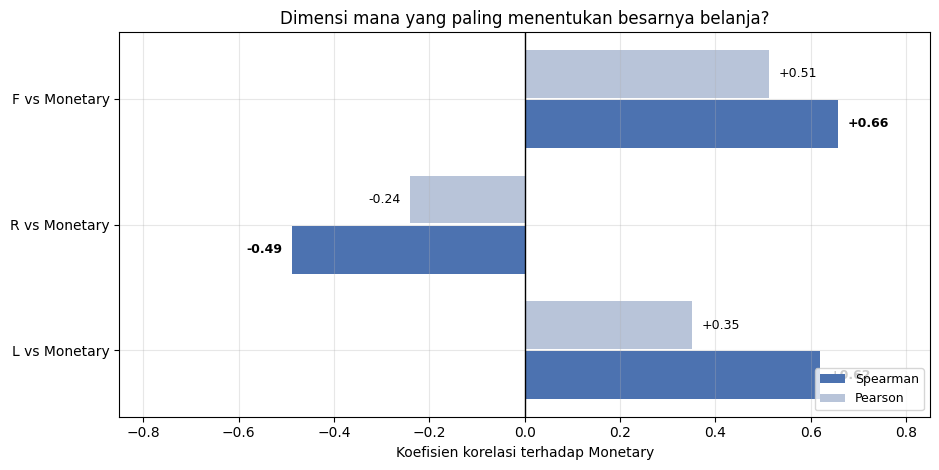

In [18]:
# 5.5b Korelasi terhadap M saja, disandingkan Spearman vs Pearson. Jarak antara kedua
# batang menunjukkan seberapa besar hubungan itu tersembunyi di balik kecondongan data.
banding = pd.DataFrame({'Spearman': spearman['M'].drop('M'),
                        'Pearson': pearson['M'].drop('M')})
fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(banding))
ax.barh(y - 0.2, banding['Spearman'], height=0.38, color='#4C72B0', label='Spearman')
ax.barh(y + 0.2, banding['Pearson'], height=0.38, color='#B8C4D9', label='Pearson')
for i, (s, p_) in enumerate(zip(banding['Spearman'], banding['Pearson'])):
    ax.text(s + (0.02 if s >= 0 else -0.02), i - 0.2, f'{s:+.2f}', va='center',
            ha='left' if s >= 0 else 'right', fontsize=9, fontweight='bold')
    ax.text(p_ + (0.02 if p_ >= 0 else -0.02), i + 0.2, f'{p_:+.2f}', va='center',
            ha='left' if p_ >= 0 else 'right', fontsize=9)
ax.set_yticks(y, [f'{k} vs Monetary' for k in banding.index])
ax.axvline(0, color='black', lw=1)
ax.set_xlim(-0.85, 0.85)
ax.set_xlabel('Koefisien korelasi terhadap Monetary')
ax.set_title('Dimensi mana yang paling menentukan besarnya belanja?')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


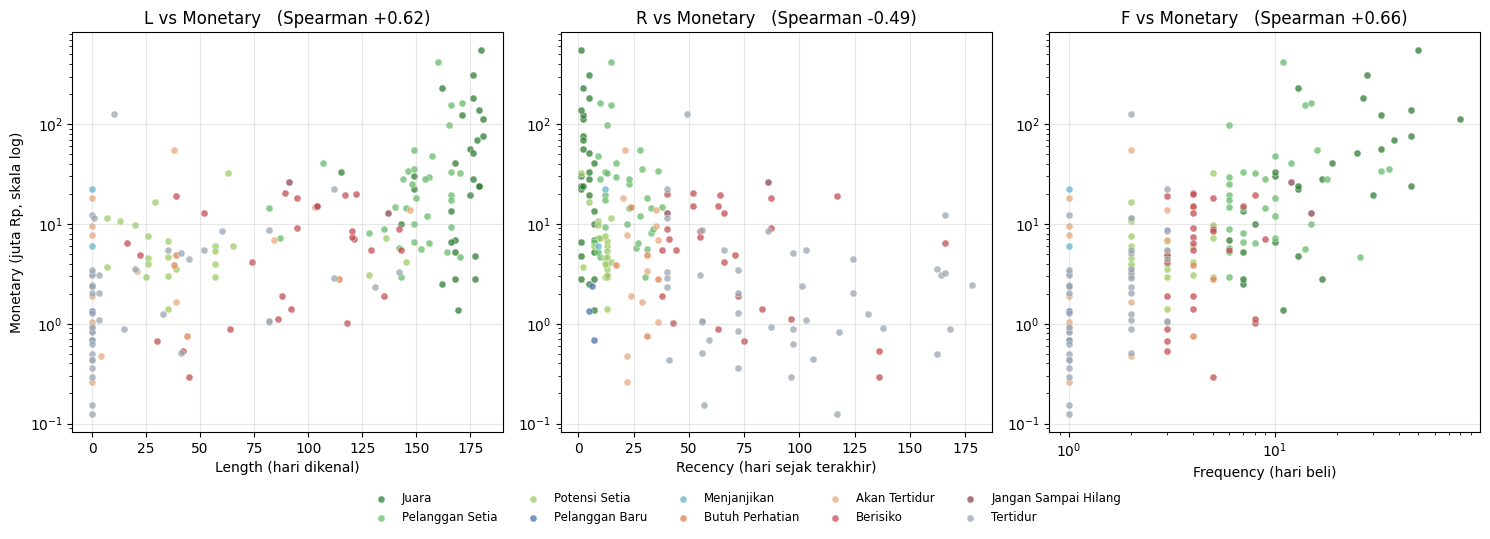

In [19]:
# 5.5c Sebar-titik tiap dimensi terhadap Monetary, satu titik satu pelanggan, diwarnai
# menurut segmen. Angka korelasi meringkas arah hubungan; gambar ini menunjukkan
# bentuknya -- termasuk bahwa hubungan R vs M lebih berupa "pagar" daripada garis:
# pelanggan lama-tak-beli hampir tidak pernah bernilai besar, tetapi pelanggan yang
# baru beli belum tentu bernilai besar.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, kol, judul in zip(axes, ['L', 'R', 'F'],
                          ['Length (hari dikenal)', 'Recency (hari sejak terakhir)',
                           'Frequency (hari beli)']):
    for s in profil.index:
        sub = lrfm[lrfm['SEGMEN'] == s]
        ax.scatter(sub[kol], sub['M'] / 1e6, s=26, color=WARNA_SEGMEN[s],
                   alpha=0.75, edgecolor='white', lw=0.4, label=s)
    ax.set_yscale('log')
    ax.set_xlabel(judul)
    ax.set_title(f'{kol} vs Monetary   (Spearman {spearman.loc[kol, "M"]:+.2f})')
    if kol == 'F':
        ax.set_xscale('log')
axes[0].set_ylabel('Monetary (juta Rp, skala log)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=8.5, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()


### 5.6 Daftar kerja: pelanggan bernilai tertinggi di segmen prioritas

Grafik menjawab *seberapa besar*; tabel menjawab *siapa*. Empat segmen di bawah
dipilih karena masing-masing memicu tindakan berbeda: pertahankan (`Juara`),
reaktivasi bernilai tinggi (`Jangan Sampai Hilang`, `Berisiko`), dan evaluasi
apakah masih layak dikejar (`Tertidur`).


In [20]:
# 5.6 Lima pelanggan bernilai tertinggi di tiap segmen prioritas -- daftar kerja
# untuk tim yang akan menindaklanjuti (retensi Juara, reaktivasi Berisiko, dst).
for seg in ['Juara', 'Berisiko', 'Jangan Sampai Hilang', 'Tertidur']:
    print(f'--- {seg} ---')
    display(lrfm[lrfm['SEGMEN'] == seg]
            .sort_values('M', ascending=False)
            [['PELANGGAN', 'L', 'R', 'F', 'M', 'TANGGAL_TERAKHIR']]
            .head(5))

--- Juara ---


,PELANGGAN,L,R,F,M,TANGGAL_TERAKHIR
151,TOKO CITA RASA BARU,180,1,50,"547,771,782.00",2020-09-30
13,ANTON,176,5,28,"311,758,150.00",2020-09-26
55,HITE,162,2,13,"229,861,080.00",2020-09-29
129,RUMAH SOSIS,176,5,27,"182,693,450.00",2020-09-26
119,PT. DINAMIKA BUAH N.,179,1,46,"139,880,850.00",2020-09-30


--- Berisiko ---


,PELANGGAN,L,R,F,M,TANGGAL_TERAKHIR
79,MALINDO PADANG,89,52,4,"20,202,640.00",2020-08-10
140,TANJUNG GADING,122,40,4,"19,787,100.00",2020-08-22
25,BRAGA FROZEN FOOD,117,64,8,"19,676,800.00",2020-07-29
102,OKE MART,39,117,3,"18,986,500.00",2020-06-06
74,MAJU JAYA,95,87,5,"18,052,500.00",2020-07-06


--- Jangan Sampai Hilang ---


,PELANGGAN,L,R,F,M,TANGGAL_TERAKHIR
41,FARDAN FROZEN,91,86,12,"26,382,900.00",2020-07-07
70,KUALU BERKAT,137,40,15,"12,828,000.00",2020-08-22


--- Tertidur ---


,PELANGGAN,L,R,F,M,TANGGAL_TERAKHIR
115,PAK SUTARMUJI,10,49,2,"126,400,000.00",2020-08-13
21,BERKAH 1,112,40,3,"22,394,350.00",2020-08-22
31,DEFRIADI,0,166,1,"12,150,000.00",2020-04-18
93,MIAMI - ZIKRI / LUKMAN,1,40,2,"11,414,000.00",2020-08-22
29,CHERISH,82,56,3,"8,702,000.00",2020-08-06


## 6. Ekspor

In [21]:
os.makedirs(DIR_KELUARAN, exist_ok=True)

KOLOM_EKSPOR = ['PELANGGAN', 'TANGGAL_PERTAMA', 'TANGGAL_TERAKHIR', 'L', 'R', 'F', 'M',
                'SKOR_L', 'SKOR_R', 'SKOR_F', 'SKOR_M', 'SEGMEN']
p_lrfm = os.path.join(DIR_KELUARAN, 'lrfm_pelanggan.csv')
lrfm[KOLOM_EKSPOR].to_csv(p_lrfm, index=False)

print(f'{p_lrfm:<35} {os.path.getsize(p_lrfm) / 1024:>8,.1f} KB')
print(f'{len(lrfm)} pelanggan diberi LRFM & segmen.')
print(f'Dikeluarkan dari segmentasi: {tunai["PELANGGAN"].nunique()} label tunai/walk-in '
      f'({", ".join(PSEUDO_PELANGGAN)}), senilai Rp {tunai["OMZET"].sum():,.0f}.')

garis = '-' * 70
print(f'\n{garis}')
print('RINGKASAN SEGMENTASI LRFM'.center(70))
print(garis)
top3 = profil.sort_values('omzet_total', ascending=False).head(3)
for seg, r in top3.iterrows():
    print(f'  {seg:<22}: {int(r["pelanggan"]):>3} pelanggan '
          f'({r["pelanggan_%"]:.0f}%)  ->  Rp {r["omzet_total"]:,.0f} omzet '
          f'({r["omzet_%"]:.0f}%)')
n_prioritas = int(profil.loc[['Berisiko', 'Jangan Sampai Hilang'], 'pelanggan'].sum())
omzet_prioritas = profil.loc[['Berisiko', 'Jangan Sampai Hilang'], 'omzet_total'].sum()
print(f'\n  Perlu tindakan retensi segera: {n_prioritas} pelanggan '
      f'(Berisiko + Jangan Sampai Hilang), Rp {omzet_prioritas:,.0f} omzet historis '
      f'yang berpotensi hilang.')
print(garis)

bersih\lrfm_pelanggan.csv               12.9 KB
180 pelanggan diberi LRFM & segmen.
Dikeluarkan dari segmentasi: 1 label tunai/walk-in (CASH), senilai Rp 167,453,770.

----------------------------------------------------------------------
                      RINGKASAN SEGMENTASI LRFM                       
----------------------------------------------------------------------
  Juara                 :  29 pelanggan (16%)  ->  Rp 2,180,336,817 omzet (49%)
  Pelanggan Setia       :  34 pelanggan (19%)  ->  Rp 1,417,122,655 omzet (32%)
  Tertidur              :  43 pelanggan (24%)  ->  Rp 258,927,900 omzet (6%)

  Perlu tindakan retensi segera: 29 pelanggan (Berisiko + Jangan Sampai Hilang), Rp 256,248,568 omzet historis yang berpotensi hilang.
----------------------------------------------------------------------
